<a href="https://colab.research.google.com/github/Kamindumenula/SE4050-Household-Waste-Classification-System/blob/main/efficientnetB0/IT23312944_efficientnetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EfficientNetB0 – Household Waste Classification (SE4050)

**Member 4.** Transfer learning with EfficientNetB0 on the shared train / val / test split.

Before running: **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**.
On a GPU the whole notebook takes roughly 10–15 minutes; on CPU it can take hours.

## 0. Common setup snippet (team version, with the val/test split fixed)

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Clone repository & extract dataset
if not os.path.exists("SE4050-Household-Waste-Classification-System"):
    !git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git

DATASET_DIR = "/content/dataset-resized"
if not os.path.exists(DATASET_DIR):
    !unzip -q -o SE4050-Household-Waste-Classification-System/dataset/archive.zip -d /content/

# Standard Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# 80% Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
classes = train_ds.class_names

# 20% Held-out Set -> Split ONCE into 10% Validation and 10% Test
# (FIX: the old take()/skip() re-shuffled the held-out images every time they were read,
#  so val and test shared images. Splitting the file list once means they never overlap
#  and are exactly the same for every member.)
held_out = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
held_paths = np.array(sorted(held_out.file_paths))
held_labels = np.array([classes.index(os.path.basename(os.path.dirname(p))) for p in held_paths])
val_paths, test_paths, val_labels, test_labels = train_test_split(
    held_paths, held_labels, test_size=0.5, stratify=held_labels, random_state=SEED
)

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    return tf.image.resize(img, IMG_SIZE), label   # 0-255 pixel values, same as train_ds

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels.astype("int32")))
    return ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)

val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)
assert not set(val_paths) & set(test_paths), "val/test overlap!"

# Performance Optimizations (Caching & Prefetching)
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Data ready! Classes ({len(classes)}): {classes}")
print(f" Batches -> Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f" Images  -> Val: {len(val_paths)} | Test: {len(test_paths)}")

Cloning into 'SE4050-Household-Waste-Classification-System'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 217 (delta 64), reused 78 (delta 27), pack-reused 75 (from 1)
Receiving objects: 100% (217/217), 66.43 MiB | 18.55 MiB/s, done.
Resolving deltas: 100% (76/76), done.
Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Data ready! Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
 Batches -> Train: 64 | Val: 8 | Test: 8
 Images  -> Val: 252 | Test: 253


## 1. Model: EfficientNetB0 + small classification head

**Why EfficientNetB0:** it scales network depth, width and input resolution together
(compound scaling) and is built from MBConv blocks with squeeze-and-excitation, so it gets
strong ImageNet accuracy with far fewer parameters than ResNet50. That makes it a good
candidate for an accurate model that is still light enough for a real waste-sorting app.

**Design choices**
- ImageNet weights, backbone frozen at first (only ~2,000 training images, so training the
  whole network from scratch would overfit).
- No manual pixel scaling: Keras' EfficientNet already contains its own rescaling and
  normalization layers and expects raw 0–255 pixels.
- Head = GlobalAveragePooling → Dropout(0.2) → Dense(6, softmax), the same head as the
  MobileNetV2 model, so the comparison between the pretrained backbones is fair.
- Backbone is called with `training=False` so BatchNorm stays in inference mode, which keeps
  fine-tuning stable.

In [2]:
import time
from tensorflow.keras.applications import EfficientNetB0

NUM_CLASSES = len(classes)
keras.utils.set_random_seed(SEED)   # same seed for weight init / dropout -> reproducible

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,), name="image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.2, name="dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="EfficientNetB0_Waste_Classifier")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_Waste_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 2. Phase 1 – train the new head (backbone frozen)
Adam (lr = 1e-3), sparse categorical cross-entropy, up to 15 epochs.
EarlyStopping (patience 3, restores the best weights) and ReduceLROnPlateau (×0.2 after 2
flat epochs) both watch **validation** loss, never the test set.

In [3]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7),
    ]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

t0 = time.time()
history_1 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=make_callbacks())
phase1_time = time.time() - t0
print(f"Phase 1 training time: {phase1_time / 60:.1f} min")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 665ms/step - accuracy: 0.6419 - loss: 1.0137 - val_accuracy: 0.7817 - val_loss: 0.6545 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8269 - loss: 0.5476 - val_accuracy: 0.8135 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8660 - loss: 0.4326 - val_accuracy: 0.8492 - val_loss: 0.4621 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8808 - loss: 0.3771 - val_accuracy: 0.8651 - val_loss: 0.4340 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8996 - loss: 0.3287 - val_accuracy: 0.8651 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9065 - loss: 0.3007 - val_accuracy: 0.8532 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9154 - loss: 0.2768 - val_a

## 3. Phase 2 – fine-tune the top of the backbone
Unfreeze the last 30 layers (the highest-level features), keep all BatchNorm layers frozen,
and use a 100× smaller learning rate (1e-5) so the pretrained weights are only nudged.
Same fine-tuning recipe as MobileNetV2 for a fair comparison.

In [4]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Backbone layers:", len(base_model.layers),
      "| trainable:", sum(l.trainable for l in base_model.layers))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

t0 = time.time()
history_2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=make_callbacks())
phase2_time = time.time() - t0
TRAIN_TIME_SEC = phase1_time + phase2_time
print(f"Phase 2 training time: {phase2_time / 60:.1f} min | total: {TRAIN_TIME_SEC / 60:.1f} min")

Backbone layers: 238 | trainable: 23
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 433ms/step - accuracy: 0.9614 - loss: 0.1567 - val_accuracy: 0.8651 - val_loss: 0.3670 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9614 - loss: 0.1421 - val_accuracy: 0.8690 - val_loss: 0.3614 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9594 - loss: 0.1317 - val_accuracy: 0.8690 - val_loss: 0.3631 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9664 - loss: 0.1224 - val_accuracy: 0.8690 - val_loss: 0.3623 - learning_rate: 1.0000e-05
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9679 - loss: 0.1167 - val_accuracy: 0.8690 - val_loss: 0.3628 - learning_rate: 2.0000e-06
Phase 2 training time: 1.1 min | total: 2.9 min


## 4. Learning curves (both phases)

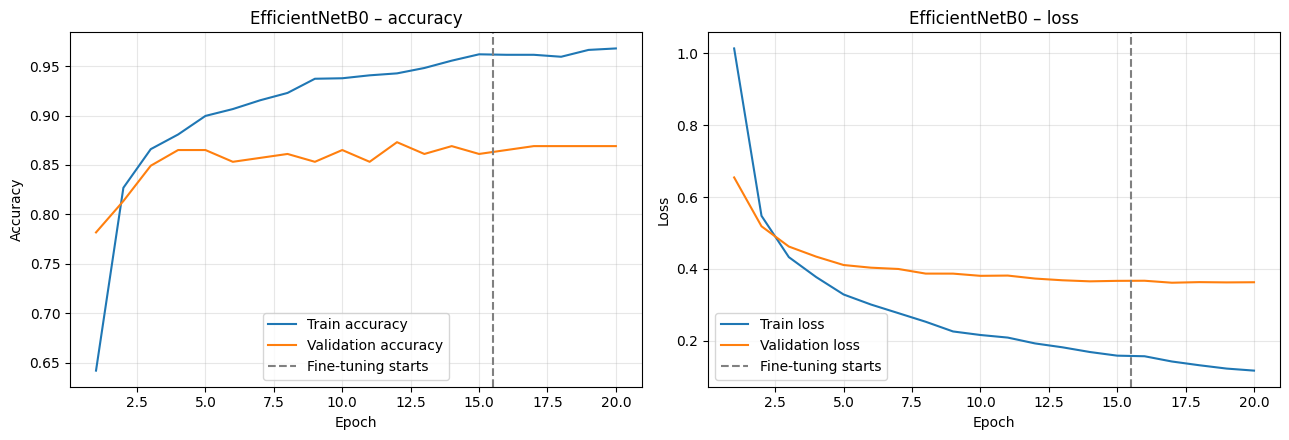

Best epoch: 17 | val_acc 0.8690 | val_loss 0.3614


In [5]:
import matplotlib.pyplot as plt

RESULTS_DIR = "efficientnetB0/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

hist = pd.concat(
    [pd.DataFrame(h.history).assign(phase=i + 1) for i, h in enumerate([history_1, history_2])],
    ignore_index=True,
)
epochs = range(1, len(hist) + 1)
split_at = len(history_1.history["loss"]) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(epochs, hist[metric], label=f"Train {metric}")
    ax.plot(epochs, hist[f"val_{metric}"], label=f"Validation {metric}")
    ax.axvline(split_at, color="grey", linestyle="--", label="Fine-tuning starts")
    ax.set_xlabel("Epoch"); ax.set_ylabel(metric.capitalize()); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title("EfficientNetB0 – accuracy"); axes[1].set_title("EfficientNetB0 – loss")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/efficientnetb0_learning_curves.png", dpi=150)
plt.show()

best = hist["val_loss"].idxmin()
print(f"Best epoch: {best + 1} | val_acc {hist.loc[best, 'val_accuracy']:.4f} | val_loss {hist.loc[best, 'val_loss']:.4f}")

## 5. Final test evaluation (run once, only after all tuning is finished)
The test set was never used for training, early stopping or learning-rate decisions.

              precision    recall  f1-score   support

   cardboard     0.8889    0.9412    0.9143        34
       glass     0.8333    0.8824    0.8571        51
       metal     0.8864    0.8864    0.8864        44
       paper     0.9355    0.9355    0.9355        62
     plastic     0.9268    0.8444    0.8837        45
       trash     0.9375    0.8824    0.9091        17

    accuracy                         0.8972       253
   macro avg     0.9014    0.8954    0.8977       253
weighted avg     0.8987    0.8972    0.8973       253

ROC-AUC (macro, one-vs-rest): 0.9854
Inference time: 55.64 ms per image


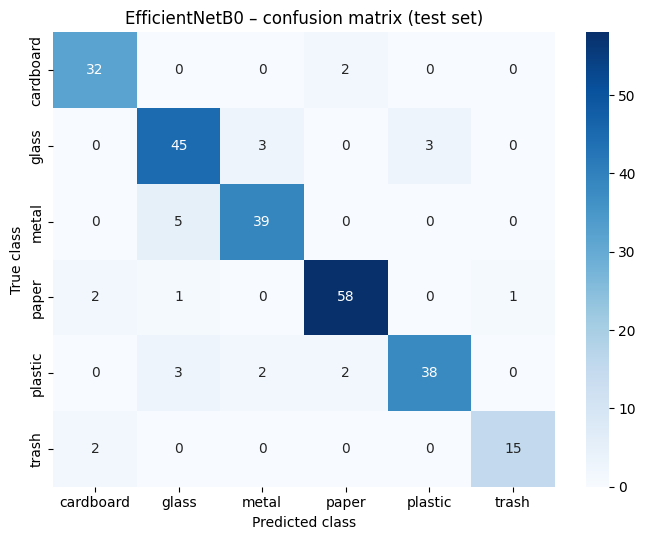

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

y_true = np.concatenate([y.numpy() for _, y in test_ds])
model.predict(test_ds.take(1), verbose=0)          # warm-up so the timing is fair
t0 = time.time()
test_probs = model.predict(test_ds, verbose=0)
infer_ms = (time.time() - t0) / len(y_true) * 1000
y_pred = test_probs.argmax(axis=1)

report = classification_report(y_true, y_pred, target_names=classes, digits=4)
print(report)
print("ROC-AUC (macro, one-vs-rest):", round(roc_auc_score(y_true, test_probs, multi_class="ovr"), 4))
print(f"Inference time: {infer_ms:.2f} ms per image")

with open(f"{RESULTS_DIR}/efficientnetb0_classification_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted class"); plt.ylabel("True class"); plt.title("EfficientNetB0 – confusion matrix (test set)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/efficientnetb0_confusion_matrix.png", dpi=150)
plt.show()

## 6. Save outputs in the shared format (used by the final comparison notebook)

In [7]:
import json

np.save(f"{RESULTS_DIR}/test_probs.npy", test_probs.astype("float32"))
np.save(f"{RESULTS_DIR}/test_labels.npy", y_true)
hist.to_csv(f"{RESULTS_DIR}/history.csv", index=False)

gpus = tf.config.list_physical_devices("GPU")
info = {
    "total_params": int(model.count_params()),
    "trainable_params": int(sum(np.prod(w.shape) for w in model.trainable_weights)),
    "train_time_sec": round(TRAIN_TIME_SEC, 1),
    "epochs_trained": int(len(hist)),
    "inference_ms_per_image": round(infer_ms, 3),
    "hardware": "GPU" if gpus else "CPU",
}
with open(f"{RESULTS_DIR}/info.json", "w") as f:
    json.dump(info, f, indent=2)
print(info)

os.makedirs("models", exist_ok=True)
model.save("models/efficientnetb0_final.keras")
print("Model and results saved.")

{'total_params': 4057257, 'trainable_params': 1491046, 'train_time_sec': 174.9, 'epochs_trained': 20, 'inference_ms_per_image': 55.644, 'hardware': 'GPU'}
Model and results saved.


## 7. Download everything to upload to GitHub
Upload the contents of the zip into the matching repo folders
(`efficientnetB0/results/`, `models/`, `splits/`) using **Add file → Upload files**, with a clear
commit message such as *"Add EfficientNetB0 training results and test outputs"*.
Save this notebook to the repo with **File → Save a copy in GitHub**.

In [8]:
!zip -r -q efficientnetB0_outputs.zip efficientnetB0/results models/efficientnetb0_final.keras splits
from google.colab import files
files.download("efficientnetB0_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>